In [1]:
import numpy as np
import hockey.hockey_env as h_env
import gymnasium as gym
from importlib import reload
import time

In [2]:
np.set_printoptions(suppress=True)

In [3]:
# reload(h_env)

# Normal Game Play

In [4]:
env = h_env.HockeyEnv()

have a look at the initialization condition: alternating who starts and are random in puck position

In [6]:
obs, info = env.reset()
obs_agent2 = env.obs_agent_two()
_ = env.render()

one episode with random agents

In [7]:
obs, info = env.reset()
obs_agent2 = env.obs_agent_two()

for _ in range(600):
    env.render(mode="human")
    a1 = np.random.uniform(-1,1,4)
    a2 = np.random.uniform(-1,1,4)    
    obs, r, d, t, info = env.step(np.hstack([a1,a2]))    
    obs_agent2 = env.obs_agent_two()
    if d or t: break

Without rendering, it runs much faster

"info" dict contains useful proxy rewards and winning information

In [8]:
info, env.get_info_agent_two()

({'winner': 0,
  'reward_closeness_to_puck': 0.0,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': 0.0},
 {'winner': 0,
  'reward_closeness_to_puck': -0.08715172334939733,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': -0.0})

Winner == 0: draw

Winner == 1: you (left player)

Winner == -1: opponent wins (right player)

In [9]:
env.close()

# Train Shooting

In [68]:
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_SHOOTING)

In [69]:
o, info = env.reset()
_ = env.render()

for _ in range(50):
    env.render()
    a1 = [1,0,0,1] # np.random.uniform(-1,1,4)
    a2 = [0,0.,0,0] 
    obs, r, d, t , info = env.step(np.hstack([a1,a2]))
    obs_agent2 = env.obs_agent_two()
    if d or t: break

In [70]:
env.close()

# Train DEFENDING

In [24]:
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_DEFENSE)

In [29]:
o, info = env.reset()
_ = env.render()

for _ in range(60):
    env.render()
    a1 = [0.1,0,0,1] # np.random.uniform(-1,1,3)
    a2 = [0,0.,0,0] 
    obs, r, d, t, info = env.step(np.hstack([a1,a2]))
    print(r)
    obs_agent2 = env.obs_agent_two()
    if d or t: break

0.0
-0.4334283620539423
-0.30012467046472524
-0.19945128803285841
-0.13324211403055272
-0.11109409010226287
-0.1654006320658479
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
10.0


In [30]:
env.close()

# Using discrete actions

In [31]:
import random

In [32]:
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_SHOOTING)

In [33]:
env.reset()
for _ in range(251):
    env.render()
    a1_discrete = random.randint(0,7)
    a1 = env.discrete_to_continous_action(a1_discrete)
    a2 = [0,0.,0,0 ] 
    obs, r, d, t, info = env.step(np.hstack([a1,a2]))    
    obs_agent2 = env.obs_agent_two()
    if d or t: break

In [34]:
env.close()

# Hand-crafted Opponent

In [35]:
env = h_env.HockeyEnv()

In [36]:
o, info = env.reset()
_ = env.render()
player1 = h_env.BasicOpponent(weak=False)
player2 = h_env.BasicOpponent()

In [40]:
obs_buffer = []
reward_buffer=[]
obs, info = env.reset()
obs_agent2 = env.obs_agent_two()
for _ in range(251):
    env.render()
    a1 = player1.act(obs)
    a2 = player2.act(obs_agent2)
    obs, r, d, t, info = env.step(np.hstack([a1,a2]))    
    obs_buffer.append(obs)
    reward_buffer.append(r)
    obs_agent2 = env.obs_agent_two()
    if d or t: break
obs_buffer = np.asarray(obs_buffer)
reward_buffer = np.asarray(reward_buffer)

In [41]:
np.mean(obs_buffer,axis=0)

array([-2.26137034, -0.29939258, -0.03148873,  0.20803966, -0.02121899,
        0.18822484,  2.97111868, -0.18955529,  0.02136436, -0.1615721 ,
       -0.11770396,  0.0080293 ,  0.56773346, -0.41774199,  0.27829376,
       -0.47554068,  2.85067873,  2.37556561])

In [42]:
np.std(obs_buffer,axis=0)

array([ 0.92277575,  0.57056305,  0.65609797,  5.31465014,  2.77819757,
        3.56759231,  0.54036819,  0.39599956,  0.13299349,  2.95369574,
        0.95299059,  0.74330994,  1.87595647,  1.00328428, 21.93672597,
        8.91968214,  4.90362891,  4.60072198])

If you want to use a fixed observation scaling, this might be a reasonable choice

In [43]:
scaling = [ 1.0,  1.0 , 0.5, 4.0, 4.0, 4.0,  
            1.0,  1.0,  0.5, 4.0, 4.0, 4.0,  
            2.0, 2.0, 10.0, 10.0, 4,0 ,4,0]

In [44]:
import pylab as plt

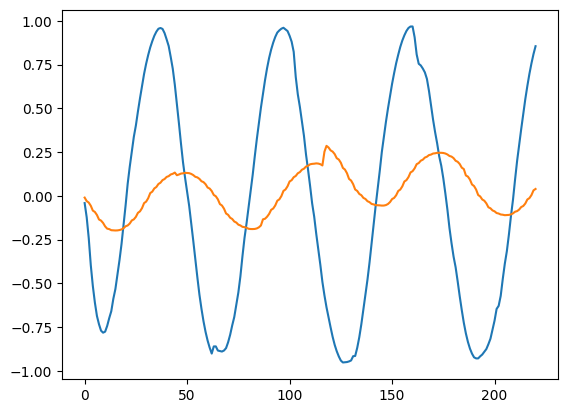

In [45]:
plt.plot(obs_buffer[:,2])
plt.plot(obs_buffer[:,8])

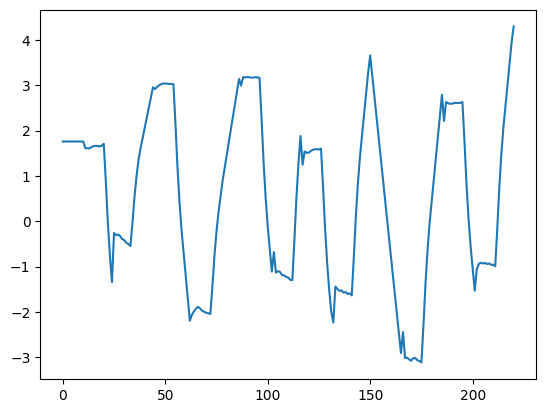

In [46]:
plt.plot(obs_buffer[:,12])

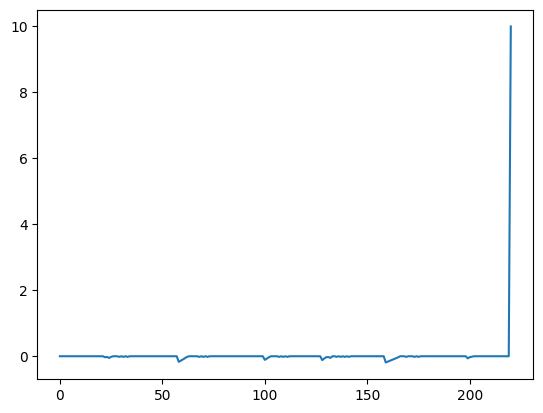

In [47]:
plt.plot(reward_buffer[:])

In [48]:
np.sum(reward_buffer)

np.float64(7.729456867776332)

In [49]:
info2 = env.get_info_agent_two()
info, info2, env.get_reward(info), env.get_reward_agent_two(info2)

({'winner': 1,
  'reward_closeness_to_puck': 0.0,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': 0.002092290954589844},
 {'winner': -1,
  'reward_closeness_to_puck': -0.12918494480107343,
  'reward_touch_puck': 0.0,
  'reward_puck_direction': -0.002092290954589844},
 10.0,
 -10.129184944801073)

In [50]:
env.close()

# Human Opponent

In [51]:
env = h_env.HockeyEnv()

In [52]:
player1 = h_env.HumanOpponent(env=env, player=1)
player2 = h_env.BasicOpponent()


Human Controls:
 left:			left arrow key left
 right:			arrow key right
 up:			arrow key up
 down:			arrow key down
 tilt clockwise:	w
 tilt anti-clockwise:	s
 shoot :	space


In [ ]:
player1 = h_env.BasicOpponent()
player2 = h_env.HumanOpponent(env=env, player=2)


In [55]:
obs, info = env.reset()

env.render()
time.sleep(1)
obs_agent2 = env.obs_agent_two()
for _ in range(10000):
    time.sleep(0.05)
    env.render()
    a1 = player1.act(obs) 
    a2 = player2.act(obs_agent2)
    obs, r, d, _, info = env.step(np.hstack([a1,a2]))    
    obs_agent2 = env.obs_agent_two()
    if d: break

In [56]:
env.close()

# Check side consistency

In [57]:
env = h_env.HockeyEnv()

In [58]:
o, info = env.reset()
_ = env.render()
player1 = h_env.BasicOpponent(weak=False)
player2 = h_env.BasicOpponent(weak=False)

In [59]:
obs_buffer = []
reward_buffer=[]
obs2_buffer = []
winner_buffer = []
reward2_buffer=[]
for game in range(1000):
    obs, info = env.reset()
    obs_agent2 = env.obs_agent_two()
    for _ in range(500):
        # env.render()
        a1 = player1.act(obs)
        a2 = player2.act(obs_agent2)
#        a1 = np.random.uniform(-1,1,4)
#        a2 = np.random.uniform(-1,1,4)    
        obs, r, d, t, info = env.step(np.hstack([a1,a2]))
        info2 = env.get_info_agent_two()
        r2 = env.get_reward_agent_two(info2)
        obs_buffer.append(obs)
        obs_agent2 = env.obs_agent_two()
        obs2_buffer.append(obs_agent2)
        reward_buffer.append(r)
        reward2_buffer.append(r2)
        if d or t:
            winner_buffer.append(info["winner"])
            break
obs_buffer = np.asarray(obs_buffer)
reward_buffer = np.asarray(reward_buffer)
obs2_buffer = np.asarray(obs2_buffer)
reward2_buffer = np.asarray(reward2_buffer)

In [60]:
obs_buffer.shape

(149676, 18)

In [61]:
np.mean(obs_buffer,axis=0)

array([-2.95478146, -0.00112201, -0.00273749, -0.0470593 ,  0.01197581,
        0.00119765,  2.97037775, -0.00743226, -0.00328248,  0.05384311,
        0.0065178 ,  0.00915512, -0.00284058, -0.00166075, -0.00635067,
       -0.00742771,  1.1252305 ,  1.13084262])

In [62]:
(np.std(obs_buffer,axis=0) - np.std(obs2_buffer,axis=0)) / np.std(obs_buffer,axis=0)

array([ 0.01374784,  0.00463856, -0.00078534,  0.00757298, -0.00655614,
       -0.00203992, -0.01393947, -0.00466018,  0.00078472, -0.00763077,
        0.00651343,  0.00203577,  0.        ,  0.        ,  0.        ,
        0.        , -0.00221376,  0.00220887])

In [63]:
winner_buffer

[1,
 0,
 0,
 0,
 0,
 -1,
 1,
 -1,
 0,
 -1,
 -1,
 0,
 0,
 -1,
 1,
 0,
 -1,
 -1,
 0,
 -1,
 0,
 -1,
 -1,
 0,
 1,
 0,
 0,
 1,
 -1,
 0,
 1,
 0,
 -1,
 -1,
 1,
 -1,
 0,
 -1,
 1,
 -1,
 1,
 1,
 -1,
 0,
 0,
 -1,
 1,
 -1,
 -1,
 -1,
 -1,
 -1,
 0,
 1,
 1,
 -1,
 0,
 0,
 -1,
 -1,
 0,
 -1,
 1,
 1,
 -1,
 1,
 -1,
 0,
 0,
 -1,
 1,
 -1,
 0,
 -1,
 1,
 1,
 1,
 0,
 1,
 -1,
 0,
 -1,
 0,
 -1,
 1,
 1,
 0,
 1,
 1,
 1,
 -1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 -1,
 0,
 0,
 0,
 1,
 0,
 -1,
 -1,
 -1,
 -1,
 1,
 0,
 1,
 -1,
 1,
 -1,
 0,
 1,
 1,
 -1,
 1,
 0,
 -1,
 -1,
 1,
 1,
 1,
 1,
 -1,
 0,
 1,
 0,
 -1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 -1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 -1,
 1,
 0,
 -1,
 0,
 -1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 -1,
 1,
 -1,
 -1,
 0,
 -1,
 -1,
 1,
 -1,
 1,
 1,
 -1,
 0,
 1,
 -1,
 1,
 0,
 -1,
 -1,
 0,
 -1,
 -1,
 0,
 -1,
 -1,
 0,
 -1,
 -1,
 0,
 1,
 -1,
 1,
 0,
 0,
 0,
 -1,
 1,
 0,
 -1,
 1,
 -1,
 1,
 1,
 1,
 -1,
 0,
 -1,
 1,
 1,
 -1,
 1,
 0,
 -1,
 -1,
 0,
 1,
 1,
 0,
 -1,
 0,
 1,
 0

In [64]:
np.mean(winner_buffer,axis=0)

np.float64(0.002)

In [65]:
np.std(winner_buffer,axis=0)

np.float64(0.8037387635295439)

In [66]:
np.sum(reward_buffer), np.sum(reward2_buffer)

(np.float64(-4104.003799269605), np.float64(-4366.191702864015))

In [67]:
env.close()